# Crop Recommendation — Exploratory Data Analysis

Sunum ve rapor için keşifsel veri analizi görselleri.

**Çıktı klasörü:** `report/assets/`  
**Kullanılmaz:** pairplot

## 0. Veri Kalitesi Kontrolleri

> **Not:** Bu EDA tüm veri seti üzerinde, train/test split **öncesi** yapılmaktadır. Modelleme aşamasında veri %80/%20 stratified olarak ayrılır (`src/data/loader.py`).

**Kontrol edilenler:** eksik değer, tekrarlayan satır, veri tipleri, sınıf dengesi, özellik aralıkları.

In [24]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import kruskal
from sklearn.preprocessing import MinMaxScaler

In [25]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_PATH, FEATURE_COLUMNS, TARGET_COLUMN

ASSETS_DIR = PROJECT_ROOT / "report" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="talk")

In [27]:
df = pd.read_csv(DATA_PATH)

PALETTE = sns.color_palette("husl", df[TARGET_COLUMN].nunique())
CROP_PALETTE = dict(zip(sorted(df[TARGET_COLUMN].unique()), PALETTE))

print(f"Shape: {df.shape}")
df.head()

Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [28]:
df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [29]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print("=== Eksik Değerler ===")
print(missing if missing.any() else "Eksik değer yok.")

print(f"\n=== Tekrarlayan Satır Sayısı ===")
print(duplicates)

print("\n=== Veri Tipleri ===")
print(df.dtypes)

=== Eksik Değerler ===
Eksik değer yok.

=== Tekrarlayan Satır Sayısı ===
0

=== Veri Tipleri ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [30]:
label_counts = df[TARGET_COLUMN].value_counts()

print("=== Hedef Değişken Analizi ===")
print(f"Benzersiz sınıf sayısı: {df[TARGET_COLUMN].nunique()}")
print(f"Sınıf başına örnek min/max: {label_counts.min()} / {label_counts.max()}")

print("\n=== Sınıf Dağılımı ===")
print(label_counts.sort_index())

=== Hedef Değişken Analizi ===
Benzersiz sınıf sayısı: 22
Sınıf başına örnek min/max: 100 / 100

=== Sınıf Dağılımı ===
label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64


In [31]:
balance_ratio = label_counts.min() / label_counts.max()

print(f"Sınıf denge oranı: {balance_ratio:.2f}")

if balance_ratio == 1:
    print("Veri seti tamamen dengeli.")
else:
    print("Veri setinde sınıf dengesizliği var.")

Sınıf denge oranı: 1.00
Veri seti tamamen dengeli.


In [32]:
range_checks = {
    "N": (0, 150),
    "P": (0, 150),
    "K": (0, 220),
    "temperature": (-10, 55),
    "humidity": (0, 100),
    "ph": (0, 14),
    "rainfall": (0, 500),
}

print("=== Aralık Dışı Değer Kontrolü ===")

for col, (lo, hi) in range_checks.items():
    out_of_range = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: {out_of_range} satır [{lo}, {hi}] dışında")

=== Aralık Dışı Değer Kontrolü ===
N: 0 satır [0, 150] dışında
P: 0 satır [0, 150] dışında
K: 0 satır [0, 220] dışında
temperature: 0 satır [-10, 55] dışında
humidity: 0 satır [0, 100] dışında
ph: 0 satır [0, 14] dışında
rainfall: 0 satır [0, 500] dışında


In [33]:
distribution_summary = pd.DataFrame({
    "skewness": df[FEATURE_COLUMNS].skew(),
    "kurtosis": df[FEATURE_COLUMNS].kurtosis()
}).round(3)

distribution_summary

,skewness,kurtosis
N,0.510,-1.058
P,1.011,0.860
K,2.375,4.449
temperature,0.185,1.233
humidity,-1.092,0.302
ph,0.284,1.656
rainfall,0.966,0.607


In [34]:
outlier_summary = []

for col in FEATURE_COLUMNS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "feature": col,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,feature,lower_bound,upper_bound,outlier_count
0,N,-73.88,179.12,0
1,P,-32.00,128.00,138
2,K,-23.50,92.50,200
3,temperature,14.08,37.25,86
4,humidity,15.73,134.48,30
5,ph,4.54,8.35,57
6,rainfall,-25.02,213.84,100


In [35]:
kruskal_results = []

for col in FEATURE_COLUMNS:
    groups = [
        df.loc[df[TARGET_COLUMN] == label, col].values
        for label in df[TARGET_COLUMN].unique()
    ]

    stat, pval = kruskal(*groups)
    sig = "anlamlı" if pval < 0.05 else "anlamlı değil"

    kruskal_results.append({
        "feature": col,
        "H_statistic": round(stat, 2),
        "p_value": pval,
        "result": sig
    })

kruskal_results = pd.DataFrame(kruskal_results)
kruskal_results

,feature,H_statistic,p_value,result
0,N,1765.36,0.000000e+00,anlamlı
1,P,2007.18,0.000000e+00,anlamlı
2,K,2065.96,0.000000e+00,anlamlı
3,temperature,1317.27,4.864444e-266,anlamlı
4,humidity,2080.32,0.000000e+00,anlamlı
5,ph,1019.87,1.630184e-202,anlamlı
6,rainfall,1944.98,0.000000e+00,anlamlı


In [36]:
eda_summary = pd.DataFrame({
    "Satır Sayısı": [df.shape[0]],
    "Sütun Sayısı": [df.shape[1]],
    "Eksik Değer Sayısı": [df.isnull().sum().sum()],
    "Tekrarlayan Satır Sayısı": [df.duplicated().sum()],
    "Sınıf Sayısı": [df[TARGET_COLUMN].nunique()],
    "Minimum Sınıf Örneği": [label_counts.min()],
    "Maksimum Sınıf Örneği": [label_counts.max()],
    "Sınıf Denge Oranı": [round(balance_ratio, 2)]
})

eda_summary

,Satır Sayısı,Sütun Sayısı,Eksik Değer Sayısı,Tekrarlayan Satır Sayısı,Sınıf Sayısı,Minimum Sınıf Örneği,Maksimum Sınıf Örneği,Sınıf Denge Oranı
0,2200,8,0,0,22,100,100,1.0


# Feature Engineering

In [37]:
from src.feature_engineering import (
    add_engineered_features,
    get_engineered_feature_columns
)

df_fe = add_engineered_features(df)

ENGINEERED_FEATURES = get_engineered_feature_columns()

df_fe.head()

,N,P,K,temperature,humidity,ph,rainfall,label,NPK_Total,N_to_P,N_to_K,P_to_K,ph_distance,Soil_Fertility,Climate_Index
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.093023,2.045455,0.954545,0.497015,61.5,347465.470778
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.440678,2.023810,1.380952,0.038096,63.7,396328.905875
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.071429,1.333333,1.222222,0.840207,53.7,499880.875700
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.055556,1.804878,0.853659,0.019599,52.1,515717.625581
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.813953,1.813953,0.976744,0.628473,56.4,431571.123386


In [38]:
df_fe[ENGINEERED_FEATURES].describe().round(2)

,NPK_Total,N_to_P,N_to_K,P_to_K,ph_distance,Soil_Fertility,Climate_Index
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,152.06,1.60,1.60,1.59,0.76,50.67,193898.49
std,79.92,2.27,1.43,1.12,0.55,25.25,141912.88
min,17.00,0.00,0.00,0.09,0.00,5.50,16803.60
25%,94.00,0.34,0.54,0.69,0.34,30.38,94124.09
50%,146.00,0.87,1.33,1.23,0.67,50.40,155173.01
75%,179.00,1.90,2.10,2.45,1.08,62.60,245114.61
max,385.00,19.83,8.75,5.00,3.50,119.40,964383.33


In [39]:
ALL_FEATURES = FEATURE_COLUMNS + ENGINEERED_FEATURES

## 1. Crop Distribution (22 ürün)

**Yorum:** Veri seti mükemmel dengeli — her ürün tam 100 örnek içeriyor. Sınıf dengesizliği problemi yok; bu, modelin tüm ürünleri eşit öğrenmesini sağlar.

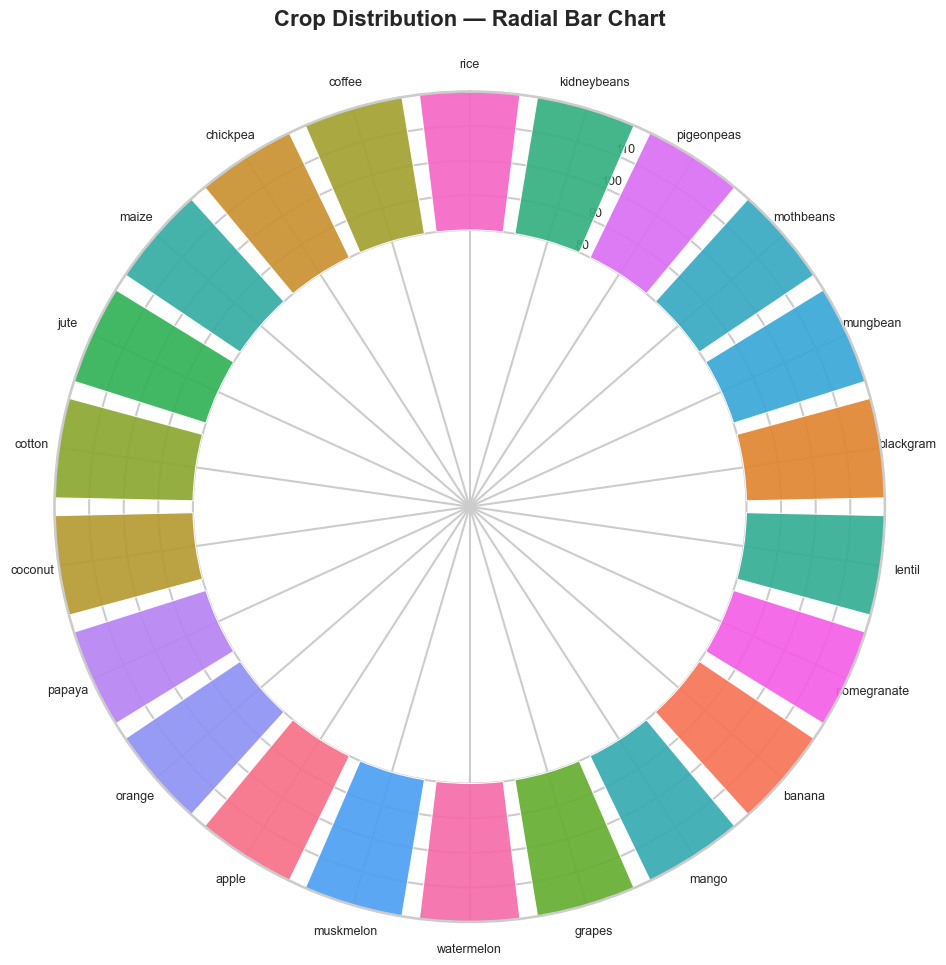

In [2]:
counts = df[TARGET_COLUMN].value_counts().sort_values()
colors = [CROP_PALETTE[c] for c in counts.index]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": "polar"})
angles = np.linspace(0, 2 * np.pi, len(counts), endpoint=False)
width = 2 * np.pi / len(counts) * 0.85
bars = ax.bar(angles, counts.values, width=width, bottom=80, color=colors, edgecolor="white", linewidth=0.8, alpha=0.92)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_ylim(0, 120)
ax.set_yticks([80, 90, 100, 110])
ax.set_yticklabels(["80", "90", "100", "110"], fontsize=9)
ax.set_xticks(angles)
ax.set_xticklabels(counts.index, fontsize=9)
ax.set_title("Crop Distribution — Radial Bar Chart", pad=24, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "01_crop_distribution.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Correlation Heatmap

**Yorum:** P ve K arasında güçlü pozitif korelasyon (0.74) var. Nem ile sıcaklık arasında zayıf negatif ilişki görülüyor. pH diğer özelliklerle bağımsız — kendi başına ayırt edici.

Original Feature Correlation

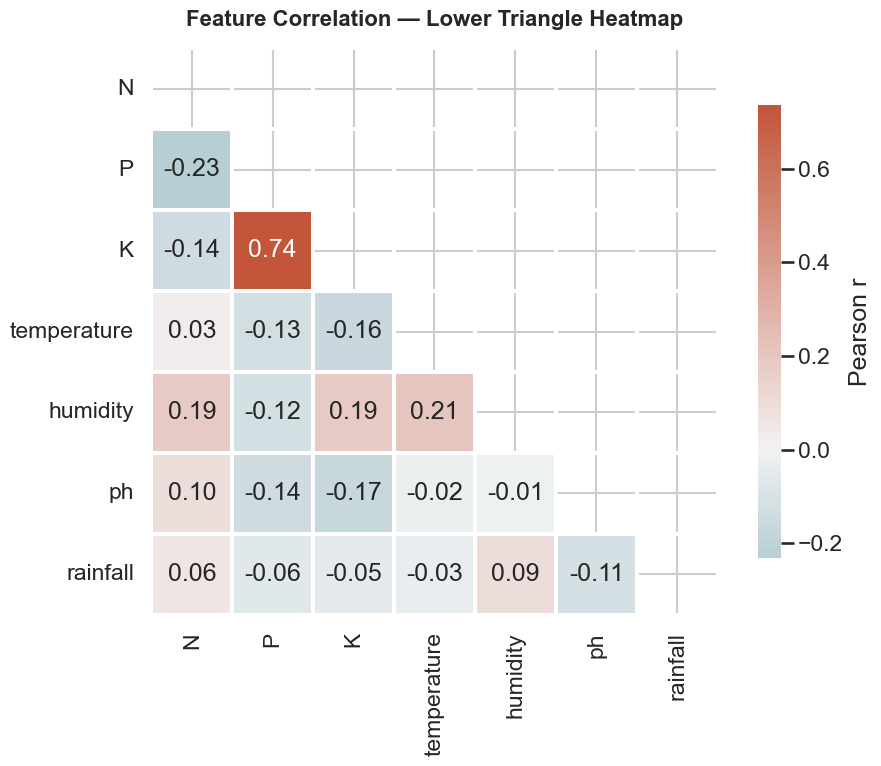

In [3]:
corr = df[FEATURE_COLUMNS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    square=True,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Feature Correlation — Lower Triangle Heatmap", fontsize=16, fontweight="bold", pad=16)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "02_correlation_heatmap.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

Original + Engineered Feature Correlation

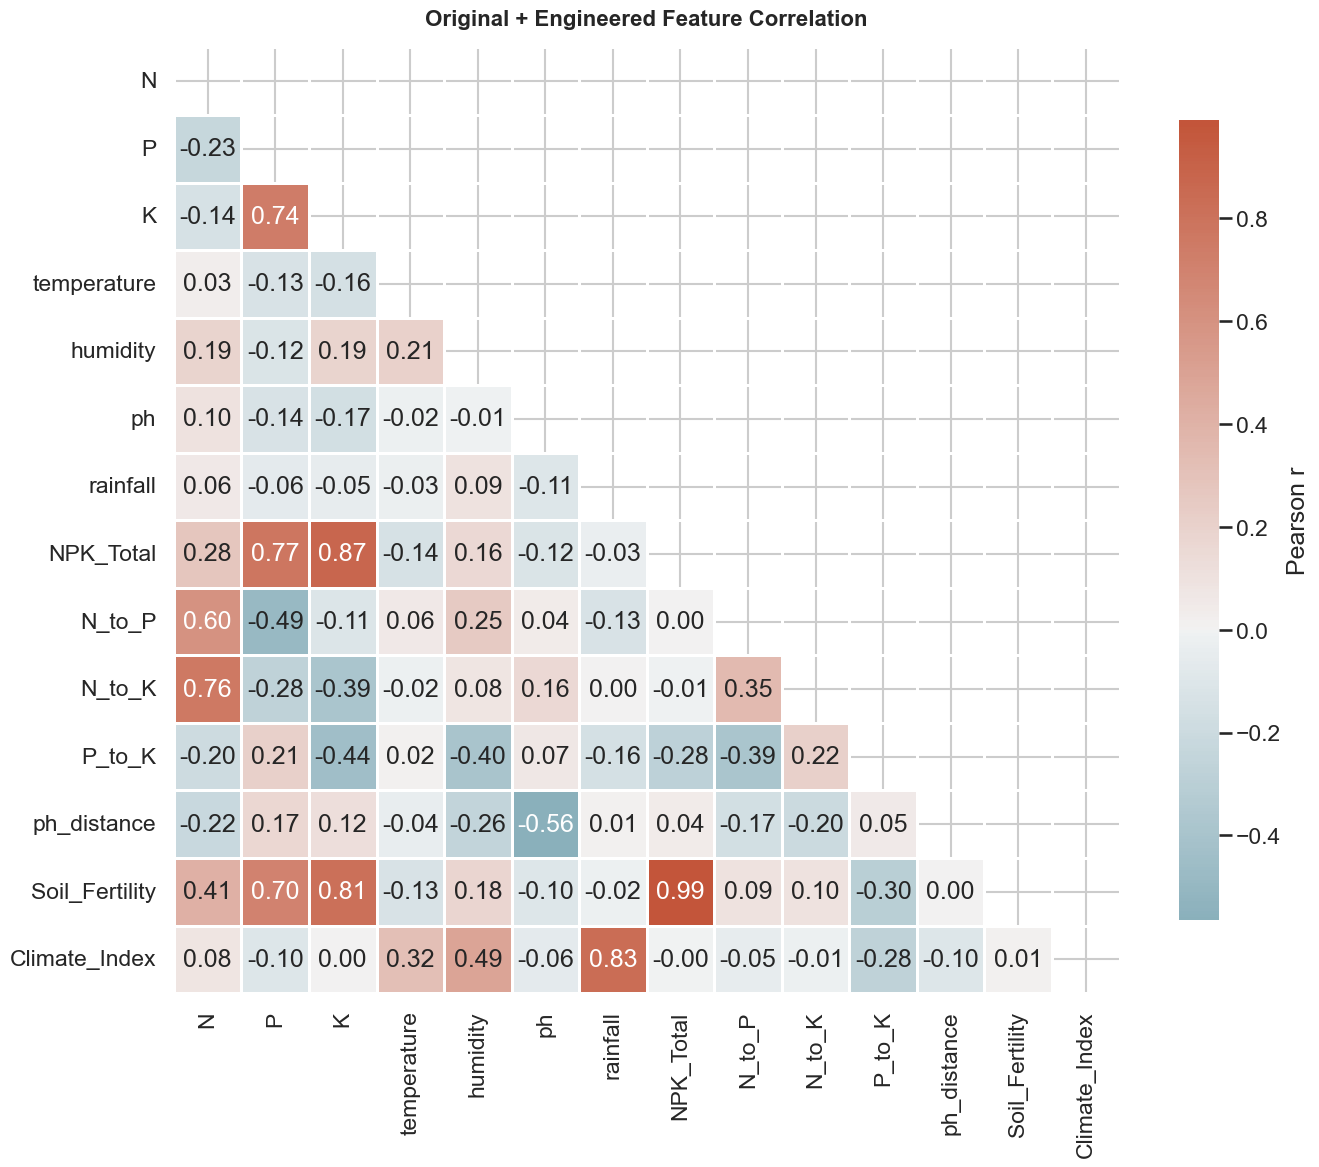

In [40]:
ALL_FEATURES = FEATURE_COLUMNS + ENGINEERED_FEATURES

corr = df_fe[ALL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson r"
    },
    ax=ax,
)

ax.set_title(
    "Original + Engineered Feature Correlation",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.tight_layout()

plt.savefig(
    ASSETS_DIR / "02_feature_engineering_correlation.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 3. Feature Histograms

**Yorum:** N ve P normal dağılıma yakın; K sağa çarpık (yüksek potasyum değerleri). Yağış geniş aralıkta yayılıyor — farklı iklim bölgelerini temsil ediyor.

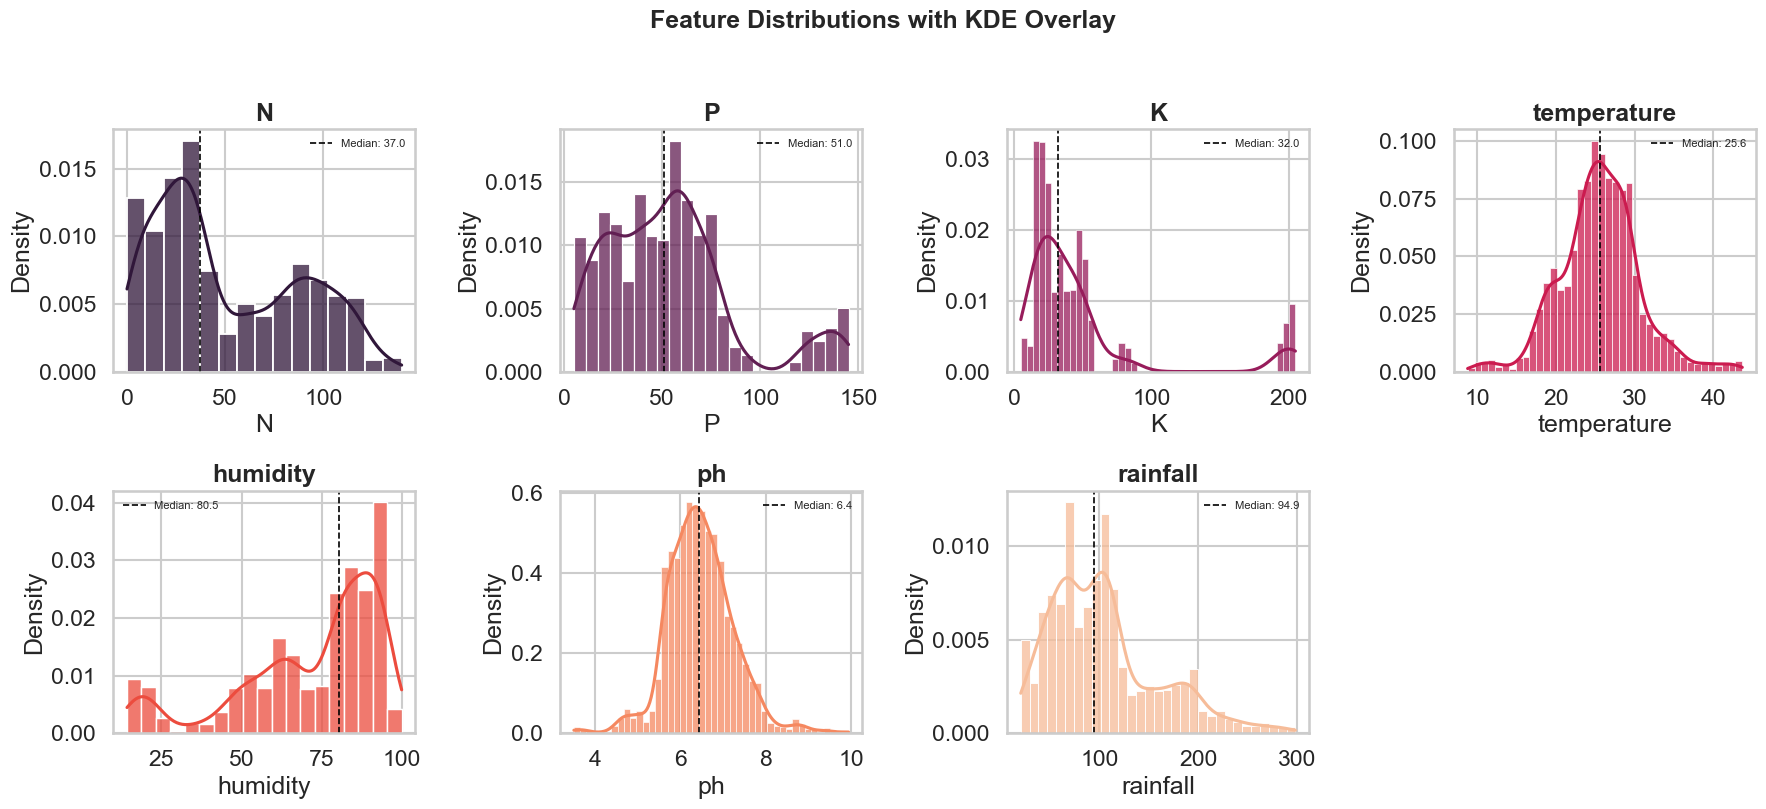

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
hist_colors = sns.color_palette("rocket", len(FEATURE_COLUMNS))

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    sns.histplot(df[col], kde=True, stat="density", color=hist_colors[i], edgecolor="white", ax=ax, alpha=0.75)
    ax.axvline(df[col].median(), color="black", ls="--", lw=1.2, label=f"Median: {df[col].median():.1f}")
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle("Feature Distributions with KDE Overlay", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "03_feature_histograms.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

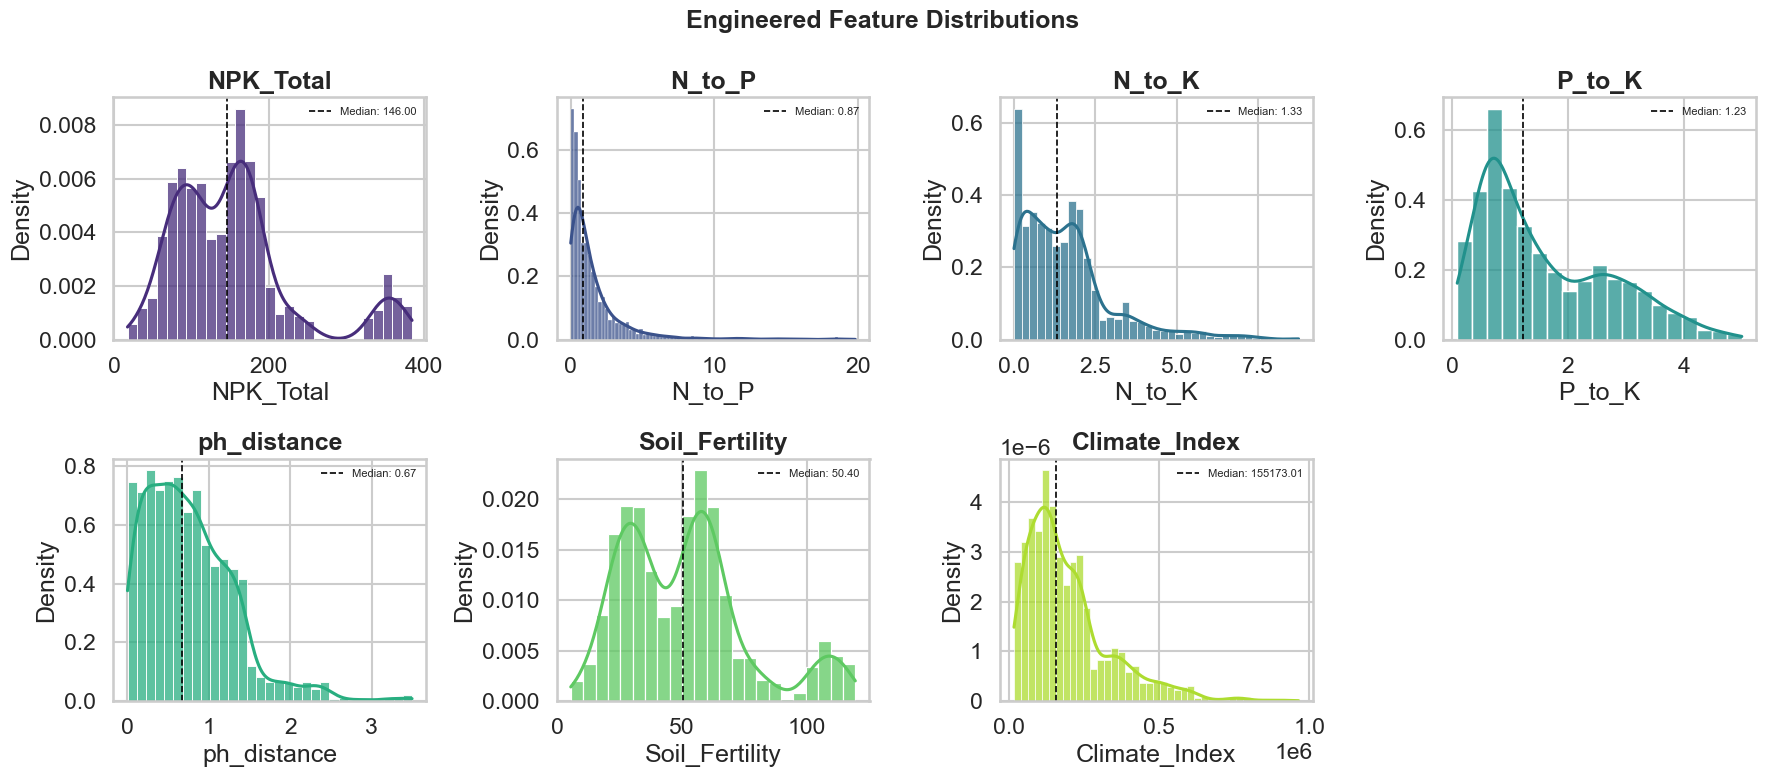

In [41]:
engineered_features = [
    "NPK_Total",
    "N_to_P",
    "N_to_K",
    "P_to_K",
    "ph_distance",
    "Soil_Fertility",
    "Climate_Index"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette("viridis", len(engineered_features))

for i, col in enumerate(engineered_features):
    ax = axes[i]

    sns.histplot(
        df_fe[col],
        kde=True,
        stat="density",
        color=colors[i],
        edgecolor="white",
        alpha=0.75,
        ax=ax
    )

    ax.axvline(
        df_fe[col].median(),
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Median: {df_fe[col].median():.2f}"
    )

    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8)

axes[-1].axis("off")

fig.suptitle(
    "Engineered Feature Distributions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    ASSETS_DIR / "15_engineered_feature_histograms.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 4. Feature Boxplots

**Yorum:** K ve rainfall en fazla aykırı değere sahip. Nem ve pH dar aralıkta — aykırı değer riski düşük. StandardScaler bu aykırı değerleri yönetmek için yeterli.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21276\808064400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


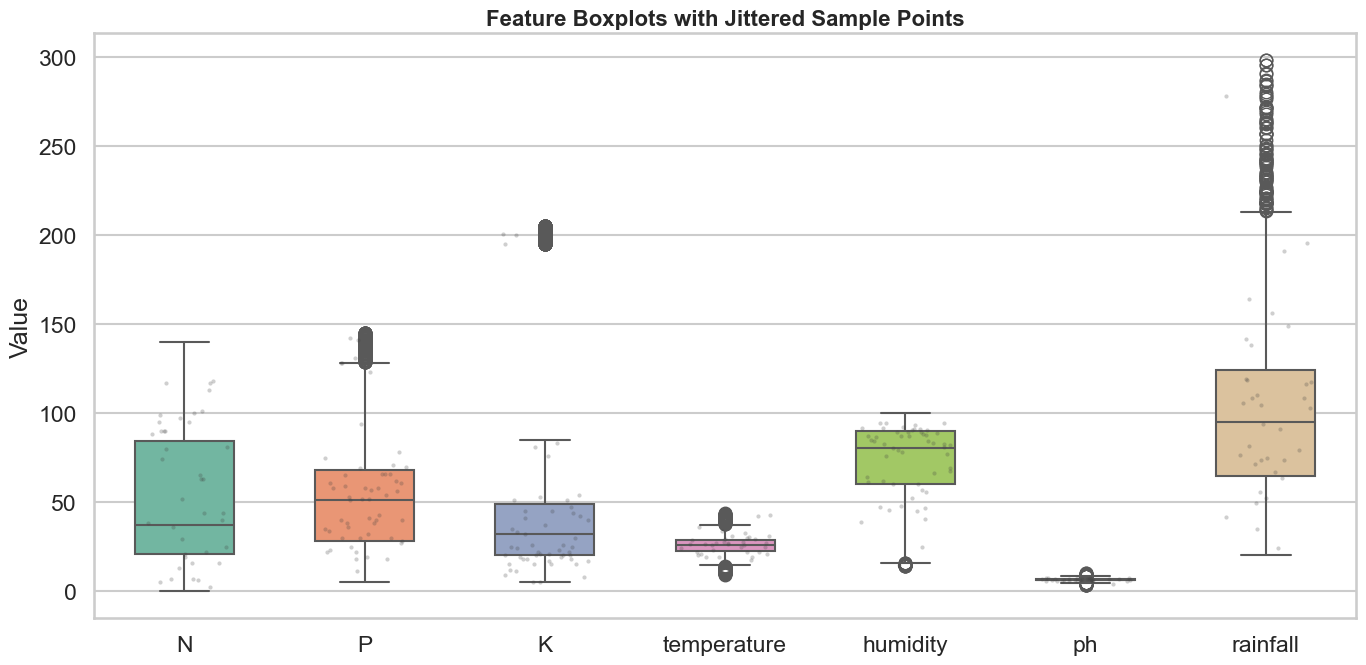

In [5]:
melted = df[FEATURE_COLUMNS].melt(var_name="Feature", value_name="Value")

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(
    data=melted,
    x="Feature",
    y="Value",
    palette="Set2",
    width=0.55,
    linewidth=1.5,
    ax=ax,
)
sns.stripplot(
    data=melted.sample(300, random_state=42),
    x="Feature",
    y="Value",
    color="0.25",
    alpha=0.25,
    size=3,
    jitter=0.25,
    ax=ax,
)
ax.set_title("Feature Boxplots with Jittered Sample Points", fontsize=16, fontweight="bold")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "04_feature_boxplots.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

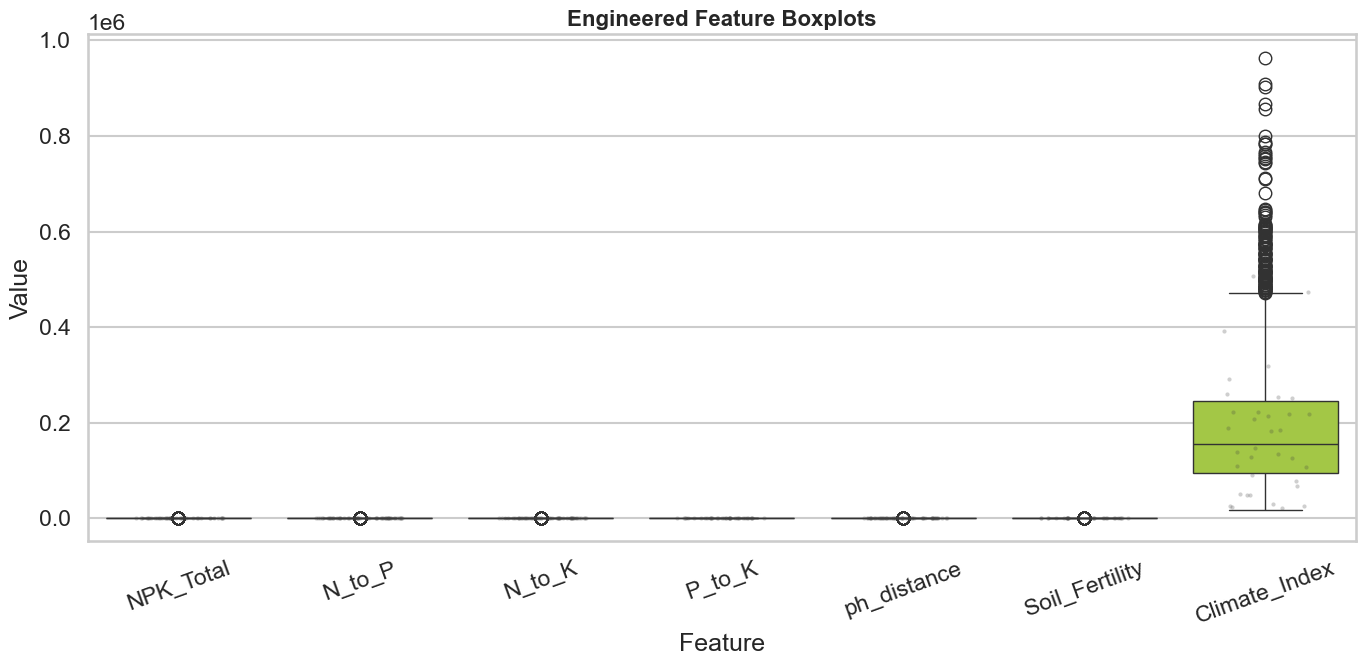

In [43]:
engineered_features = [
    "NPK_Total",
    "N_to_P",
    "N_to_K",
    "P_to_K",
    "ph_distance",
    "Soil_Fertility",
    "Climate_Index"
]

melted_fe = df_fe[engineered_features].melt(
    var_name="Feature",
    value_name="Value"
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=melted_fe,
    x="Feature",
    y="Value",
    hue="Feature",
    legend=False,
    palette="viridis"
)

sns.stripplot(
    data=melted_fe.sample(min(300, len(melted_fe)), random_state=42),
    x="Feature",
    y="Value",
    color="0.25",
    alpha=0.25,
    size=3,
    jitter=0.25,
    ax=ax
)

ax.set_title(
    "Engineered Feature Boxplots",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    ASSETS_DIR / "16_engineered_feature_boxplots.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 5. Rainfall vs Crop

**Yorum:** Coconut ve rice yüksek yağış istiyor (>170 mm). Blackgram ve chickpea düşük yağışlı bölgelere uyumlu. Yağış, ürün ayrımında güçlü bir ayırt edici.

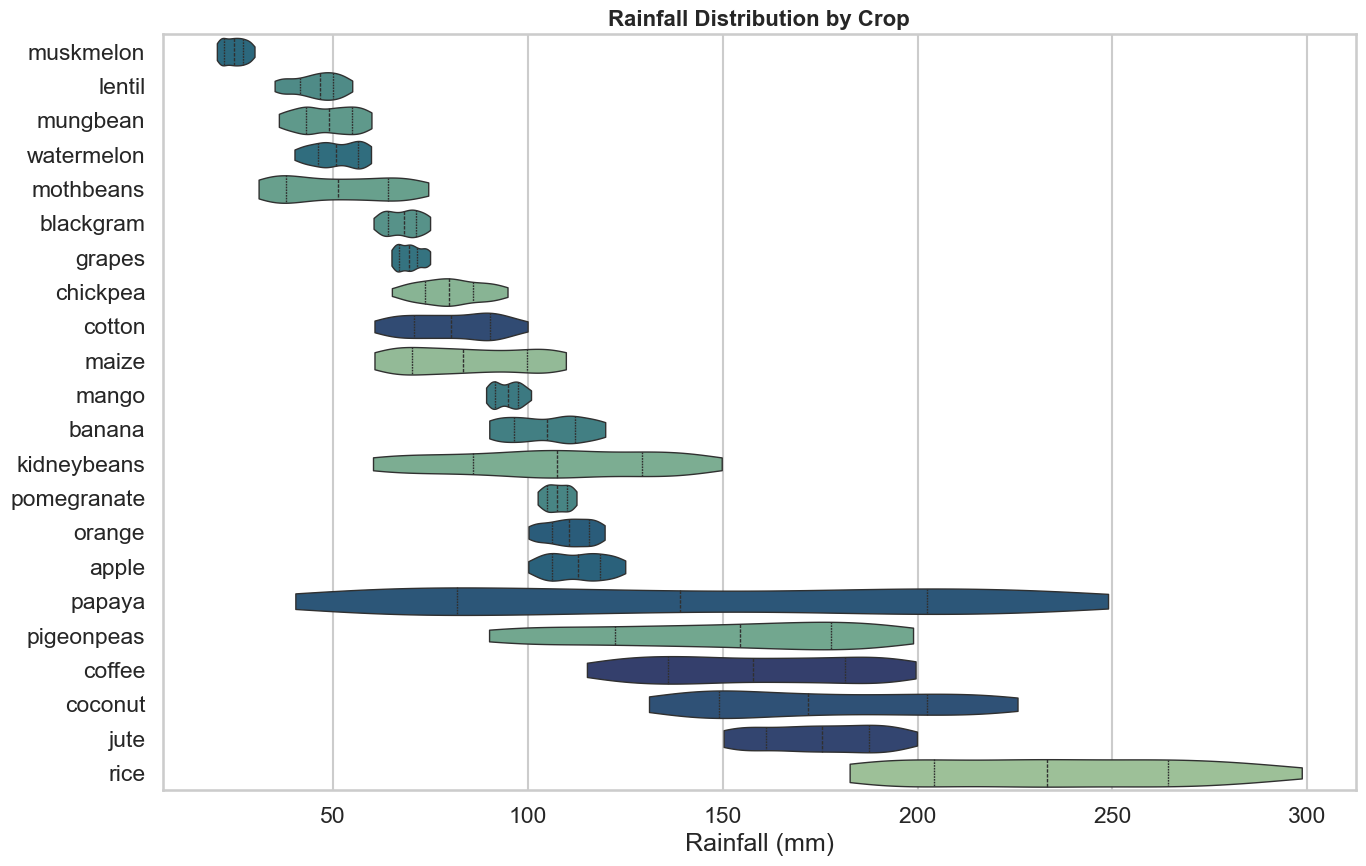

In [44]:
order = df.groupby(TARGET_COLUMN)["rainfall"].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 9))

sns.violinplot(
    data=df,
    y=TARGET_COLUMN,
    x="rainfall",
    order=order,
    hue=TARGET_COLUMN,
    palette="crest",
    inner="quartile",
    cut=0,
    linewidth=1,
    legend=False,
    ax=ax,
)

ax.set_title("Rainfall Distribution by Crop", fontsize=16, fontweight="bold")
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "05_rainfall_vs_crop.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 6. pH vs Crop

**Yorum:** Chickpea ve lentil alkali toprakları (pH ~7.3) tercih ediyor. Cotton ve grapes asidik topraklarda (pH ~6.3) yetişiyor. pH, baklagil vs diğer ürün ayrımında kritik.

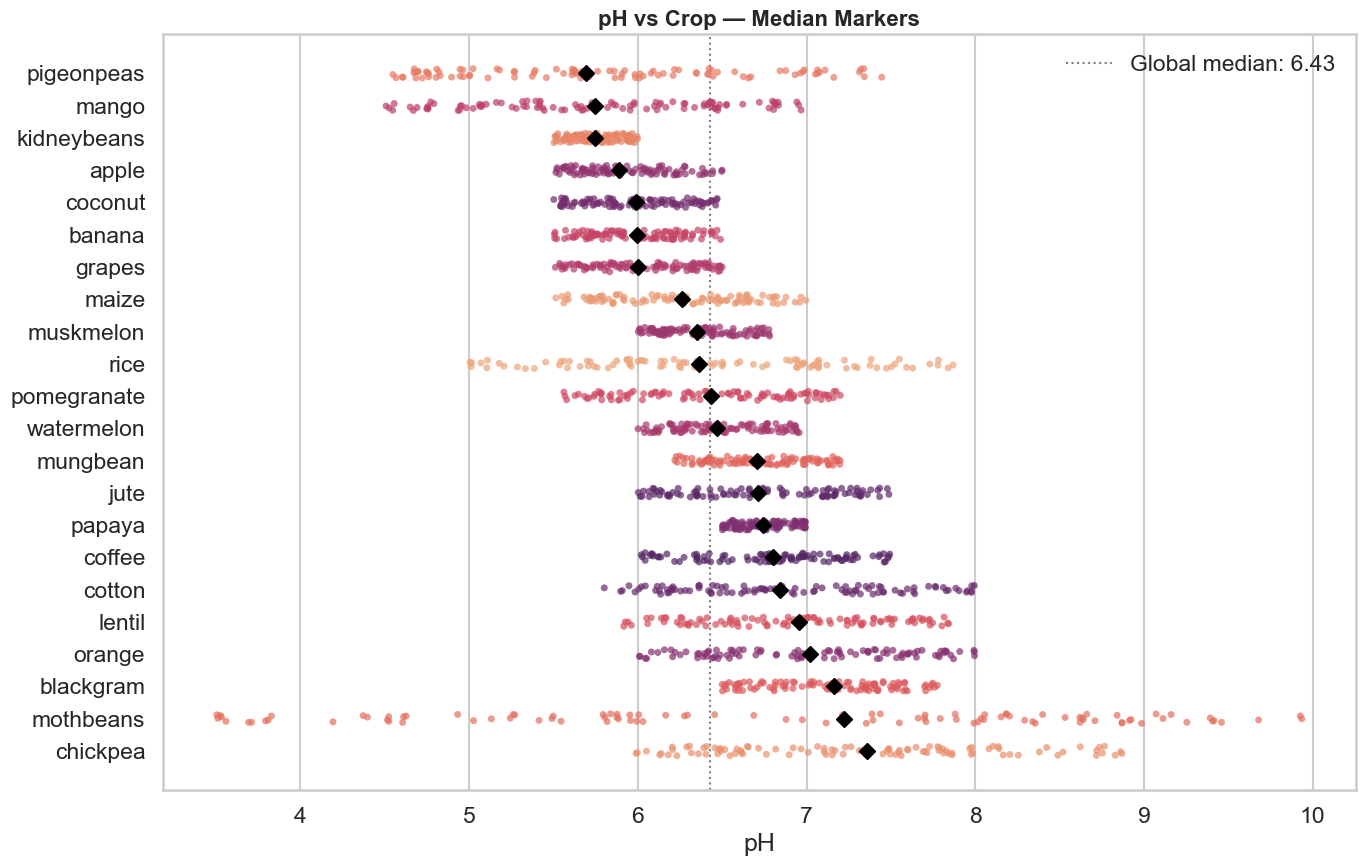

In [45]:
order_ph = df.groupby(TARGET_COLUMN)["ph"].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 9))

sns.stripplot(
    data=df,
    y=TARGET_COLUMN,
    x="ph",
    order=order_ph,
    hue=TARGET_COLUMN,
    palette="flare",
    size=5,
    alpha=0.7,
    jitter=0.15,
    legend=False,
    ax=ax,
)

medians = (
    df.groupby(TARGET_COLUMN)["ph"]
    .median()
    .reindex(order_ph)
)

for i, (crop, med) in enumerate(medians.items()):
    ax.plot(
        med,
        i,
        "D",
        color="black",
        markersize=8,
        zorder=5
    )

ax.axvline(
    df["ph"].median(),
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label=f"Global median: {df['ph'].median():.2f}"
)

ax.set_title(
    "pH vs Crop — Median Markers",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("pH")
ax.set_ylabel("")
ax.legend()

plt.tight_layout()

plt.savefig(
    ASSETS_DIR / "06_ph_vs_crop.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 7. Humidity vs Crop

**Yorum:** Rice ve jute yüksek nem (%85+) gerektiriyor. Muskmelon ve watermelon daha kuru koşullara toleranslı. Nem profili tropikal vs kurak ürünleri ayırıyor.

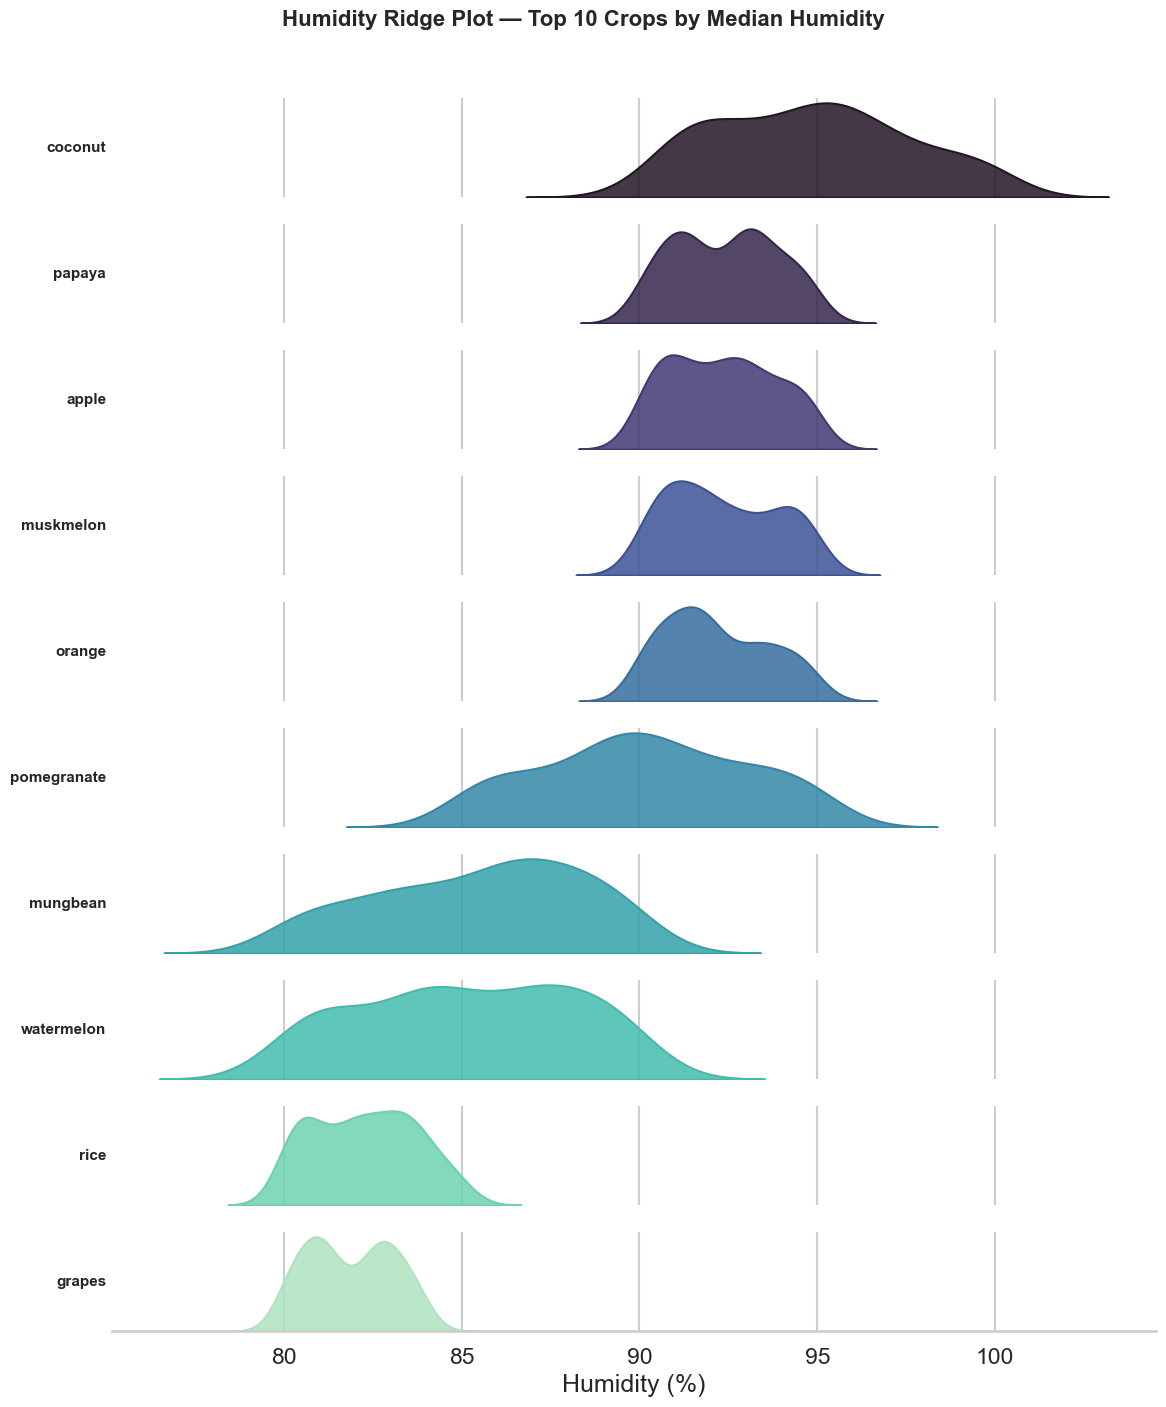

In [8]:
top_crops = df.groupby(TARGET_COLUMN)["humidity"].median().sort_values(ascending=False).index[:10]
subset = df[df[TARGET_COLUMN].isin(top_crops)]

fig, axes = plt.subplots(len(top_crops), 1, figsize=(12, 14), sharex=True)
ridge_colors = sns.color_palette("mako", len(top_crops))

for i, (crop, ax) in enumerate(zip(top_crops, axes)):
    values = subset.loc[subset[TARGET_COLUMN] == crop, "humidity"]
    sns.kdeplot(values, fill=True, alpha=0.85, color=ridge_colors[i], ax=ax, linewidth=1.5)
    ax.set_ylabel(crop, rotation=0, ha="right", va="center", fontsize=11, fontweight="bold")
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if i < len(top_crops) - 1:
        ax.spines["bottom"].set_visible(False)
        ax.set_xlabel("")

axes[-1].set_xlabel("Humidity (%)")
fig.suptitle("Humidity Ridge Plot — Top 10 Crops by Median Humidity", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "07_humidity_vs_crop.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 8. N-P-K Dağılımları

**Yorum:** Her ürünün farklı NPK profili var. Cotton yüksek azot, chickpea düşük fosfor tercih ediyor. NPK üçlüsü birlikte ürün kararını belirliyor.

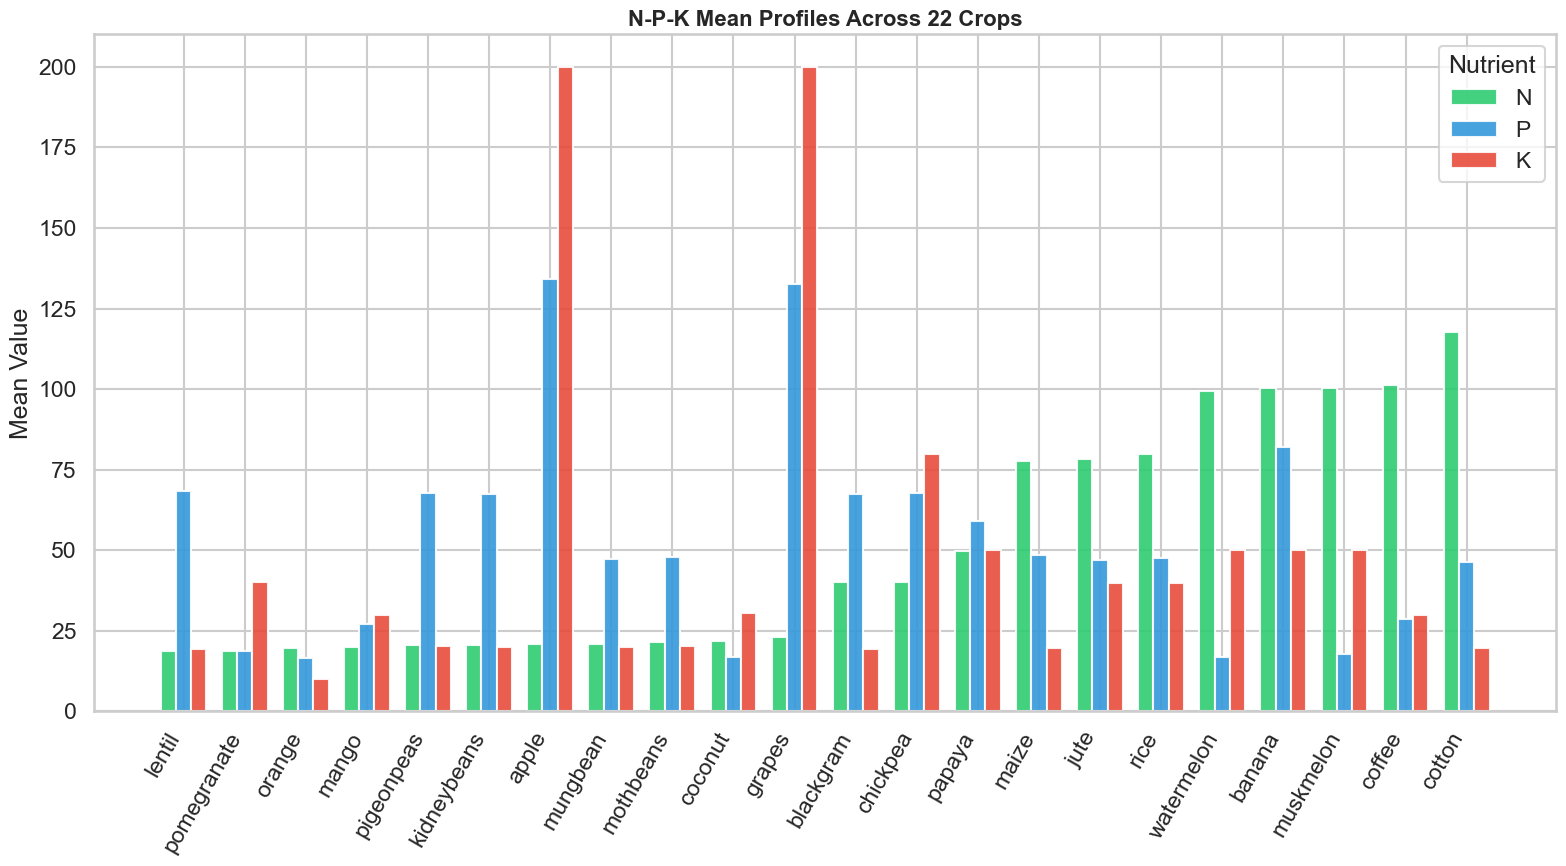

In [9]:
npk_cols = ["N", "P", "K"]
crop_means = df.groupby(TARGET_COLUMN)[npk_cols].mean().sort_values("N")

fig, ax = plt.subplots(figsize=(16, 9))
x = np.arange(len(crop_means))
width = 0.25
colors_npk = ["#2ecc71", "#3498db", "#e74c3c"]

for i, col in enumerate(npk_cols):
    ax.bar(x + i * width, crop_means[col], width, label=col, color=colors_npk[i], edgecolor="white", alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(crop_means.index, rotation=60, ha="right")
ax.set_ylabel("Mean Value")
ax.set_title("N-P-K Mean Profiles Across 22 Crops", fontsize=16, fontweight="bold")
ax.legend(title="Nutrient", frameon=True)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "08_npk_distributions.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

---
## Ek Görseller (Standart Dışı)

Aşağıdaki grafikler projeyi daha iyi anlatmak için eklenmiştir.

### 9. Radar Chart — Ürün Profilleri

**Yorum:** 6 temsili ürünün çevresel profili bir arada görülüyor. Rice yüksek nem+yağış, cotton yüksek azot, chickpea alkali pH ile öne çıkıyor.

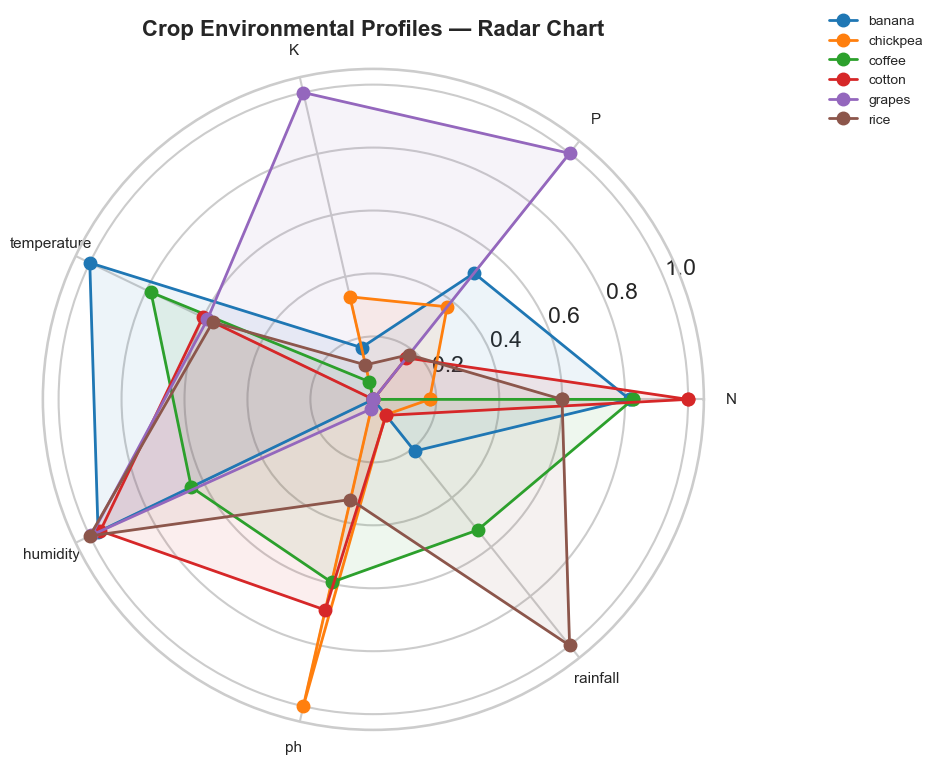

In [10]:
sample_crops = ["rice", "cotton", "chickpea", "banana", "grapes", "coffee"]
radar_df = df[df[TARGET_COLUMN].isin(sample_crops)].groupby(TARGET_COLUMN)[FEATURE_COLUMNS].mean()
scaler = MinMaxScaler()
radar_scaled = pd.DataFrame(scaler.fit_transform(radar_df), columns=FEATURE_COLUMNS, index=radar_df.index)

labels = FEATURE_COLUMNS
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "polar"})
radar_colors = sns.color_palette("tab10", len(sample_crops))

for i, crop in enumerate(radar_scaled.index):
    values = radar_scaled.loc[crop].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=crop, color=radar_colors[i])
    ax.fill(angles, values, alpha=0.08, color=radar_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Crop Environmental Profiles — Radar Chart", fontsize=16, fontweight="bold", pad=24)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "09_radar_crop_profiles.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

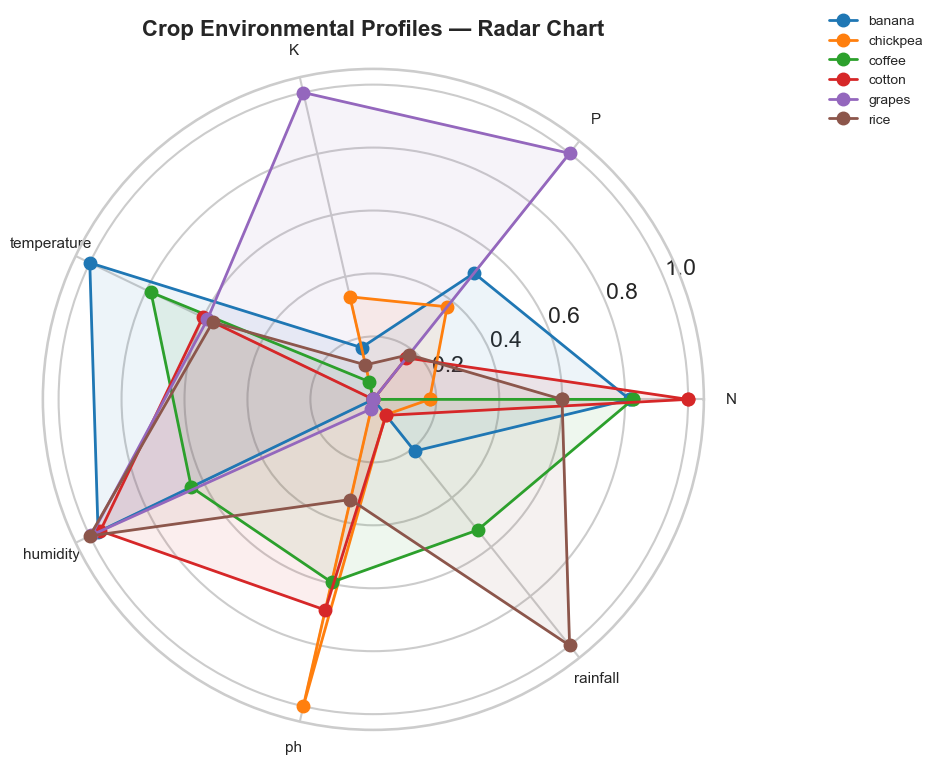

In [46]:
sample_crops = ["rice", "cotton", "chickpea", "banana", "grapes", "coffee"]
radar_df = df[df[TARGET_COLUMN].isin(sample_crops)].groupby(TARGET_COLUMN)[FEATURE_COLUMNS].mean()
scaler = MinMaxScaler()
radar_scaled = pd.DataFrame(scaler.fit_transform(radar_df), columns=FEATURE_COLUMNS, index=radar_df.index)

labels = FEATURE_COLUMNS
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "polar"})
radar_colors = sns.color_palette("tab10", len(sample_crops))

for i, crop in enumerate(radar_scaled.index):
    values = radar_scaled.loc[crop].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=crop, color=radar_colors[i])
    ax.fill(angles, values, alpha=0.08, color=radar_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title("Crop Environmental Profiles — Radar Chart", fontsize=16, fontweight="bold", pad=24)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "09_radar_crop_profiles.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 10. Parallel Coordinates — Çok Boyutlu Profil

**Yorum:** 8 ürünün 7 özellik boyunca yolları farklı kümeler oluşturuyor. Paralel koordinatlar, hangi özellik kombinasyonlarının hangi ürünleri ayırdığını gösterir.

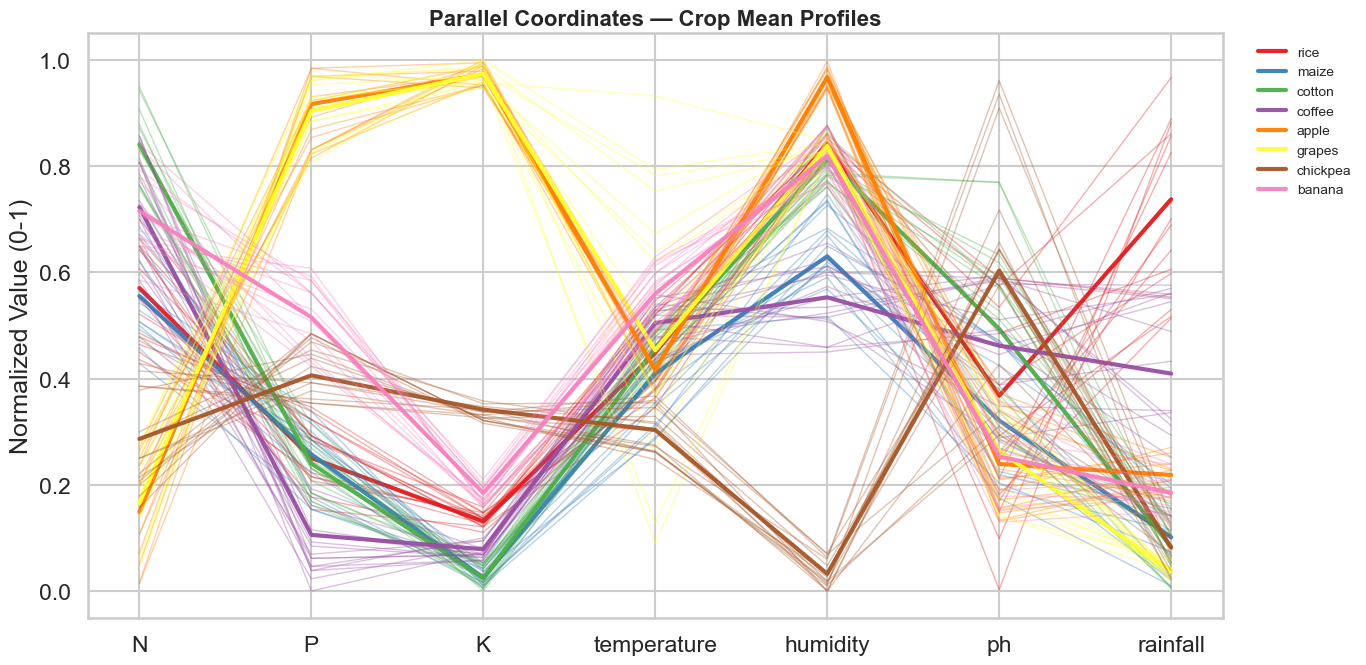

In [11]:
pc_crops = ["rice", "maize", "cotton", "coffee", "apple", "grapes", "chickpea", "banana"]
pc_df = df[df[TARGET_COLUMN].isin(pc_crops)].copy()
pc_scaled = pc_df.copy()
pc_scaled[FEATURE_COLUMNS] = MinMaxScaler().fit_transform(pc_df[FEATURE_COLUMNS])

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(FEATURE_COLUMNS))
crop_colors = dict(zip(pc_crops, sns.color_palette("Set1", len(pc_crops))))

for crop in pc_crops:
    subset = pc_scaled[pc_scaled[TARGET_COLUMN] == crop]
    for _, row in subset.sample(min(15, len(subset)), random_state=42).iterrows():
        y = row[FEATURE_COLUMNS].values
        ax.plot(x, y, color=crop_colors[crop], alpha=0.35, linewidth=1)
    mean_profile = subset[FEATURE_COLUMNS].mean()
    ax.plot(x, mean_profile, color=crop_colors[crop], linewidth=3, label=crop, alpha=0.95)

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_ylabel("Normalized Value (0-1)")
ax.set_title("Parallel Coordinates — Crop Mean Profiles", fontsize=16, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "10_parallel_coordinates.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 11. Climate Bubble Chart

**Yorum:** Sıcaklık-yağış düzleminde ürün kümeleri net ayrılıyor. Sol alt (serin+kuru) = chickpea/lentil; sağ üst (sıcak+yağışlı) = coconut/banana.

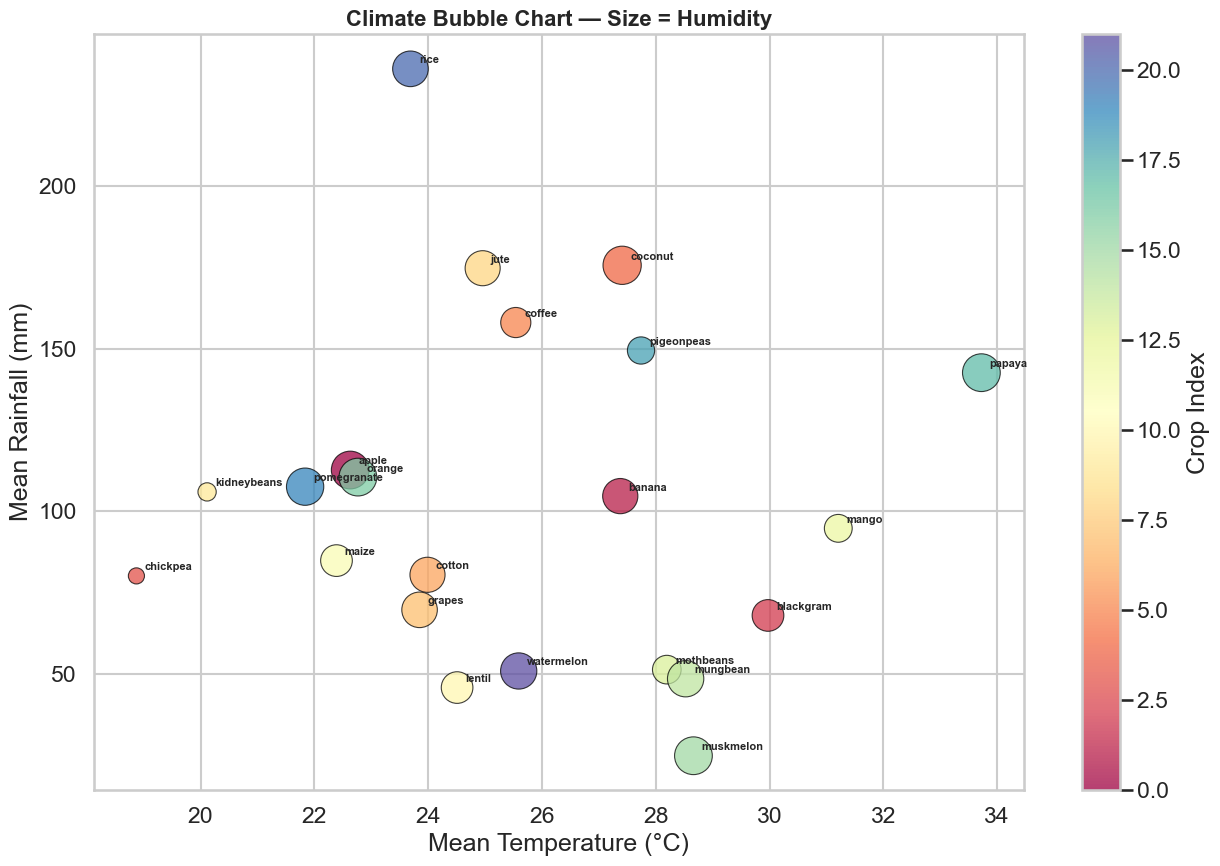

In [12]:
bubble = df.groupby(TARGET_COLUMN).agg(
    temperature=("temperature", "mean"),
    rainfall=("rainfall", "mean"),
    humidity=("humidity", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(13, 9))
scatter = ax.scatter(
    bubble["temperature"],
    bubble["rainfall"],
    s=bubble["humidity"] * 8,
    c=range(len(bubble)),
    cmap="Spectral",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.8,
)
for _, row in bubble.iterrows():
    ax.annotate(
        row[TARGET_COLUMN],
        (row["temperature"], row["rainfall"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        fontweight="bold",
    )
ax.set_xlabel("Mean Temperature (°C)")
ax.set_ylabel("Mean Rainfall (mm)")
ax.set_title("Climate Bubble Chart — Size = Humidity", fontsize=16, fontweight="bold")
plt.colorbar(scatter, ax=ax, label="Crop Index")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "11_climate_bubble_chart.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 12. N vs P Hexbin — Besin Yoğunluk Haritası

**Yorum:** N-P düzleminde veri yoğunluğu merkezi bir bölgede toplanıyor. Uç değerler farklı ürün profillerine karşılık geliyor — model bu bölgeleri ayırt etmeli.

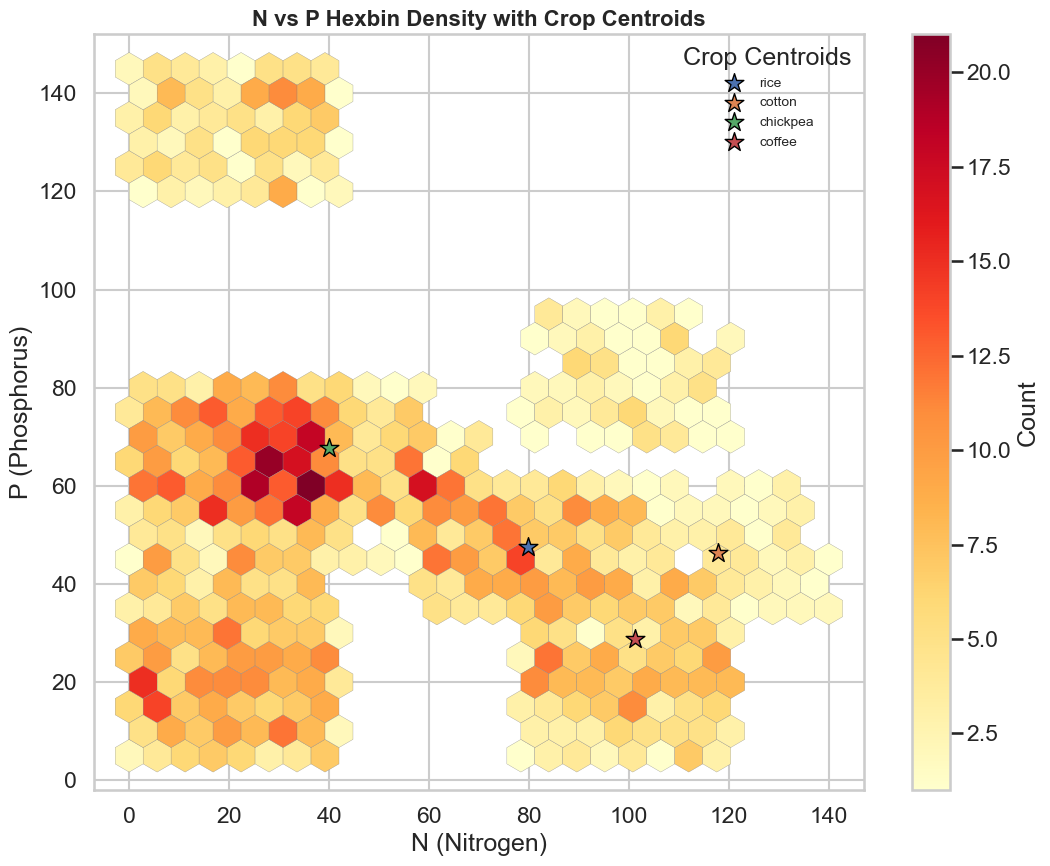

In [13]:
fig, ax = plt.subplots(figsize=(11, 9))
hb = ax.hexbin(df["N"], df["P"], gridsize=25, cmap="YlOrRd", mincnt=1, edgecolors="gray", linewidths=0.2)
plt.colorbar(hb, ax=ax, label="Count")

for crop in ["rice", "cotton", "chickpea", "coffee"]:
    sub = df[df[TARGET_COLUMN] == crop]
    ax.scatter(sub["N"].mean(), sub["P"].mean(), s=200, marker="*", edgecolors="black", linewidth=1, label=crop, zorder=5)

ax.set_xlabel("N (Nitrogen)")
ax.set_ylabel("P (Phosphorus)")
ax.set_title("N vs P Hexbin Density with Crop Centroids", fontsize=16, fontweight="bold")
ax.legend(title="Crop Centroids", fontsize=10)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "12_n_vs_p_hexbin.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 13. Temperature Ridge Plot — Sıcaklık Dağılımları

**Yorum:** Blackgram en yüksek sıcaklık aralığında, apple en düşük. Sıcaklık profili ürün gruplarını doğal olarak ayırıyor.

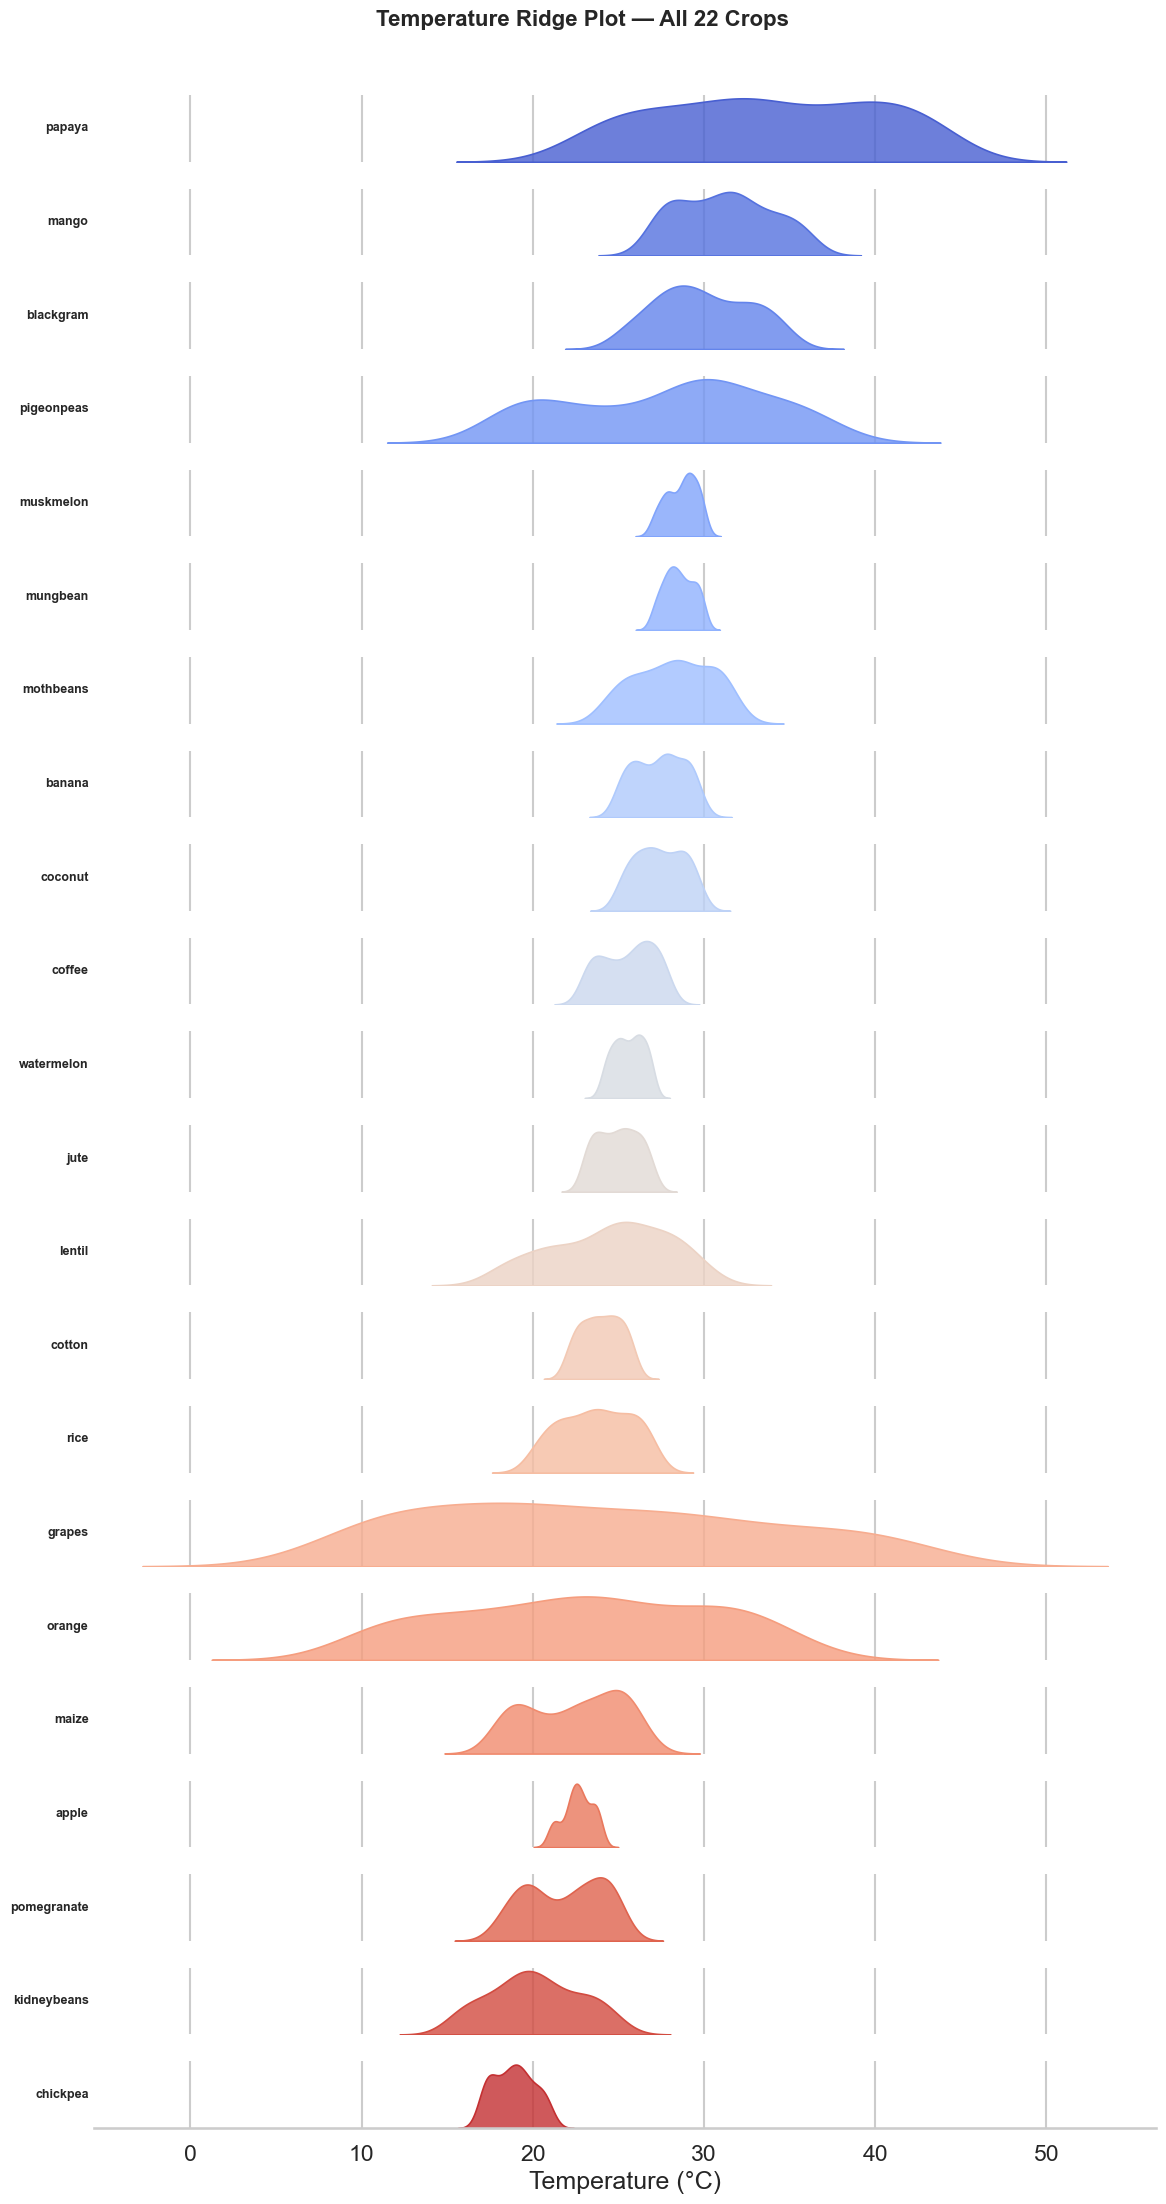

In [14]:
temp_order = df.groupby(TARGET_COLUMN)["temperature"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(len(temp_order), 1, figsize=(12, 22), sharex=True)
temp_colors = sns.color_palette("coolwarm", len(temp_order))

for i, (crop, ax) in enumerate(zip(temp_order, axes)):
    values = df.loc[df[TARGET_COLUMN] == crop, "temperature"]
    sns.kdeplot(values, fill=True, alpha=0.8, color=temp_colors[i], ax=ax, linewidth=1.2)
    ax.set_ylabel(crop, rotation=0, ha="right", va="center", fontsize=9, fontweight="bold")
    ax.set_yticks([])
    for spine in ["left", "top", "right"]:
        ax.spines[spine].set_visible(False)
    if i < len(temp_order) - 1:
        ax.spines["bottom"].set_visible(False)

axes[-1].set_xlabel("Temperature (°C)")
fig.suptitle("Temperature Ridge Plot — All 22 Crops", fontsize=16, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "13_temperature_ridge_plot.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 14. Treemap — Ürün Kategorileri

**Yorum:** Ürünler iklim ihtiyaçlarına göre gruplandı. Tropikal, kurak/toleranslı ve ılıman gruplar farklı çevresel gereksinimlere sahip.

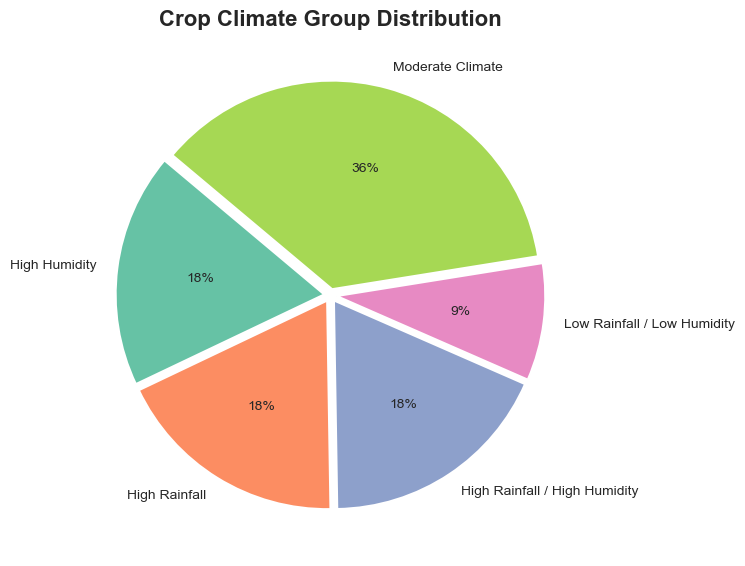

In [48]:
# Crop categories generated from data, not manually assigned

crop_climate = (
    df.groupby(TARGET_COLUMN)
    .agg(
        mean_temperature=("temperature", "mean"),
        mean_humidity=("humidity", "mean"),
        mean_rainfall=("rainfall", "mean")
    )
    .reset_index()
)

rain_q1 = crop_climate["mean_rainfall"].quantile(0.33)
rain_q2 = crop_climate["mean_rainfall"].quantile(0.66)

hum_q1 = crop_climate["mean_humidity"].quantile(0.33)
hum_q2 = crop_climate["mean_humidity"].quantile(0.66)


def assign_climate_group(row):
    if row["mean_rainfall"] >= rain_q2 and row["mean_humidity"] >= hum_q2:
        return "High Rainfall / High Humidity"

    elif row["mean_rainfall"] <= rain_q1 and row["mean_humidity"] <= hum_q1:
        return "Low Rainfall / Low Humidity"

    elif row["mean_rainfall"] >= rain_q2:
        return "High Rainfall"

    elif row["mean_humidity"] >= hum_q2:
        return "High Humidity"

    else:
        return "Moderate Climate"


crop_climate["category"] = crop_climate.apply(assign_climate_group, axis=1)

cat_counts = (
    crop_climate
    .groupby("category")
    .size()
    .reset_index(name="count")
)

cat_df = crop_climate[[TARGET_COLUMN, "category"]].copy()
cat_df["count"] = 1

try:
    import squarify

    fig, ax = plt.subplots(figsize=(14, 8))

    colors = sns.color_palette("Set3", len(cat_df))

    labels = [
        f"{row[TARGET_COLUMN]}\n{row['category']}"
        for _, row in cat_df.iterrows()
    ]

    squarify.plot(
        sizes=cat_df["count"],
        label=labels,
        color=colors,
        alpha=0.85,
        text_kwargs={"fontsize": 8, "fontweight": "bold"},
        ax=ax,
        edgecolor="white",
        linewidth=2,
    )

    ax.axis("off")
    ax.set_title(
        "Crop Treemap — Data-Driven Climate Grouping",
        fontsize=16,
        fontweight="bold"
    )

except ImportError:

    fig, ax = plt.subplots(figsize=(14, 6))

    wedges, texts, autotexts = ax.pie(
        cat_counts["count"],
        labels=cat_counts["category"],
        autopct="%1.0f%%",
        colors=sns.color_palette("Set2", len(cat_counts)),
        startangle=140,
        explode=[0.03] * len(cat_counts),
        textprops={"fontsize": 10},
    )

    ax.set_title(
        "Crop Climate Group Distribution",
        fontsize=16,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    ASSETS_DIR / "14_crop_treemap_data_driven.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Özet

Tüm grafikler `report/assets/` klasörüne kaydedildi.

In [16]:
saved = sorted(ASSETS_DIR.glob("*.png"))
print(f"Toplam {len(saved)} grafik kaydedildi:\n")
for p in saved:
    print(f"  {p.name}")

Toplam 14 grafik kaydedildi:

  01_crop_distribution.png
  02_correlation_heatmap.png
  03_feature_histograms.png
  04_feature_boxplots.png
  05_rainfall_vs_crop.png
  06_ph_vs_crop.png
  07_humidity_vs_crop.png
  08_npk_distributions.png
  09_radar_crop_profiles.png
  10_parallel_coordinates.png
  11_climate_bubble_chart.png
  12_n_vs_p_hexbin.png
  13_temperature_ridge_plot.png
  14_crop_treemap.png
